In [412]:
# magics: ensures that any changes to the modules loaded below will be re-loaded automatically
%load_ext autoreload
%autoreload 2
%load_ext line_profiler

import numpy as np
# load modules related to this exercise
import rdmodel as model
import matplotlib.pyplot as plt 
import pandas as pd
#from Solve_NFXP import solve_NFXP
#import estimate_NFXP as estimate

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
The line_profiler extension is already loaded. To reload it, use:
  %reload_ext line_profiler


# Utility

In [352]:
print(model.u(400,1000,1,4))
print(model.u(400,1000,1,5))

2.3263016196113613
1.4100108877372062


For both value functions inputs for consumption level, reference point and gain/loos parameters are the same, however with the reference point being higher than consumption level. when c_t < r_t, we are in the setting where consumption today has decreased relative to consumption in the last N periods (benefits have dropped).
It also means that the loss aversion parameter plays a role, which is greater in the second setting.
Meaning that utility drops as the loss is weigted higher at the benefit drop (this should increase hazard rate (prob of exiting unemployment) compared to that of a smaller loss aversion)



In [353]:
print(model.u(800, 600, 1, 4))
print(model.u(800, 600, 1, 5))

6.972293800119708
6.972293800119708


In this setting the consumption level is higher than the reference point, that is when income is increased relative to former period, thus loss aversion plays no role.

In [354]:
print(model.u(800, 600, 0, 5))

6.684611727667927


with the gain/loss parameter equal to 0, we don't value the gain/loss in consumption today relative to reference point. In this setting it is a gain, so the individual gets no utility from the gain relative to reference point. Means that consumer doesn't have a reference of past income and thus consumption. Had we been in a loss situation, we should expect the utility to be higher than that where gain/loss parameter was 1, as the person would not weight the disutility from a loss.

# Cost and Cost Prime Inverse

In [355]:
print("cost")
print(model.cost(0.1, 300, 0.9))
print("cost prime inverse")
print(model.cost_prime_inverse(9,12,100,.9, .995))
print(model.cost_prime_inverse(10, 12, 100, .9,.995))


cost
1.9877769659907913
cost prime inverse
0.020206621477313783
0.012877653981772352


The last two lines, shows that when k (the constant scaling parameter) in the search cost function increases, then the optimal search effort decreases. That is because k increases the cost of searching, thus in the inverse, it dereases the optimal search effort when it's increasing

# Steady State FOC

In [356]:
benefits = np.ones(40)*90
benefits[:10] =  300


In [357]:
print(model.steady_state_FOC(65, 1300, 360, .9, .995, benefits))

1043.526125459804


# Fsolve Steady State

In [358]:
print(model.steady_state_Vu(1300, 360, .9, .995, benefits))

[1258.19561913]


In [359]:
print(model.steady_state_FOC(1258.19562, 1300, 360, .9, .995, benefits))

-8.317192623508163e-08


The double check shows that we get a value very close to zero, approx: -0.00000008

# Test the model

first create array of model paramters

In [360]:
eta = 0
lam = 0
N = 0
delta = .995
gamma = .9
k = 300
params = np.array([eta, lam, N, delta, gamma, k])

Institutional paramters:
assume pre and post UI wage to be 1000
assume UI benefits of 400 is paid for first 12 periods, followed by welfare benefits of 200 for the remaining periods
We have a benefit period of 30, that is T=30


In [361]:
ben = model.benefit_path(b1=400, b2=0, b3=0, welfare=200, T1=12, T2=12, T3=12,T=30)
inst = 30, 1000, 1000, ben

In [362]:
r, s, surv, Vu, Ve = model.solveSingleTypeModel(params, inst)

In [363]:
print(f'Hazard rate in first period s[0]: {s[0]:9.5f}')

Hazard rate in first period s[0]:   0.07478


# Exploring the model

### Unemployment spells in Germany
Constant UI payments for 12 (or 18 months) after which worker gets welfare, benefits assumed to be 1100 and welfare to be 500
Pre and post UI wage is 2000
Time horizon T=30
two groups with different UI eligibility P=12 and P=18
Each period in the model is assumed to correspond to one month

### Standard Model: One type


In [364]:
eta = 0
lam = 0
N = 0
delta = .995
gamma = .9
k = 300
params = np.array([eta, lam, N, delta, gamma, k])

In [365]:
T = 30
w_pre = 2000
w_post = 2000
ben12 = model.benefit_path(b1=1100, b2=0, b3=0, welfare=500, T1=12, T2=12, T3=12,T=30)
ben18 = model.benefit_path(b1=1100, b2=0, b3=0, welfare=500, T1=18, T2=18, T3=18,T=30)
inst12 = T, w_pre, w_post, ben12
inst18 = T, w_pre, w_post, ben18

In [366]:
r12, s12, surv12, Vu12, Ve12 = model.solveSingleTypeModel(params, inst12)
r18, s18, surv18, Vu18, Ve18 = model.solveSingleTypeModel(params, inst18)

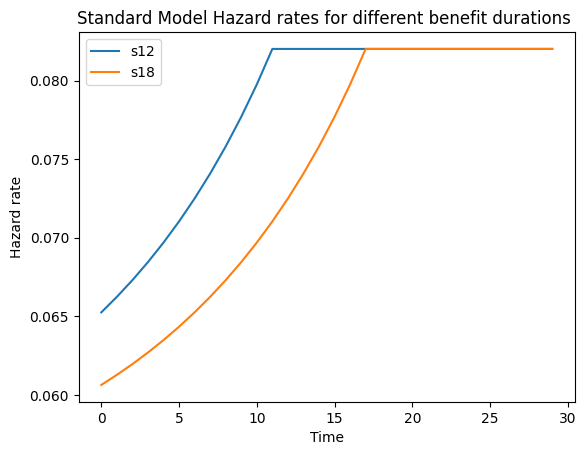

In [367]:
# plot s12 and s18 alongside each other
plt.plot(s12, label='s12')
plt.plot(s18, label='s18')
plt.xlabel('Time')
plt.ylabel('Hazard rate')
plt.title('Standard Model Hazard rates for different benefit durations ')
plt.legend()
plt.show()


The model captures how search intensity increases until the point at period at which workers enter the welfare tier level of benefits, afterwards it converges to a certain value of search effort. The Schmieder 2016 paper, show an increase in search effort around the time of switching to welfare, but the search effort once again drops.

### Reference Dependent model: One type
Assume gain-loss paramter is set to $\eta=1$, values of loss-aversion parameter $\lambda$ and reference period N, is set roughly to match Della-vigna at $\lambda=4.9$ and $N=6$, the other parameters remain the same.


In [368]:
eta = 1
lam = 4.9
N = 6
delta = .995
gamma = .9
k = 300
params = np.array([eta, lam, N, delta, gamma, k])

In [369]:
T = 30
w_pre = 2000
w_post = 2000
ben12 = model.benefit_path(b1=1100, b2=0, b3=0, welfare=500, T1=12, T2=12, T3=12,T=30)
ben18 = model.benefit_path(b1=1100, b2=0, b3=0, welfare=500, T1=18, T2=18, T3=18,T=30)
inst12 = T, w_pre, w_post, ben12
inst18 = T, w_pre, w_post, ben18

In [370]:
r12, s12, surv12, Vu12, Ve12 = model.solveSingleTypeModel(params, inst12)
r18, s18, surv18, Vu18, Ve18 = model.solveSingleTypeModel(params, inst18)

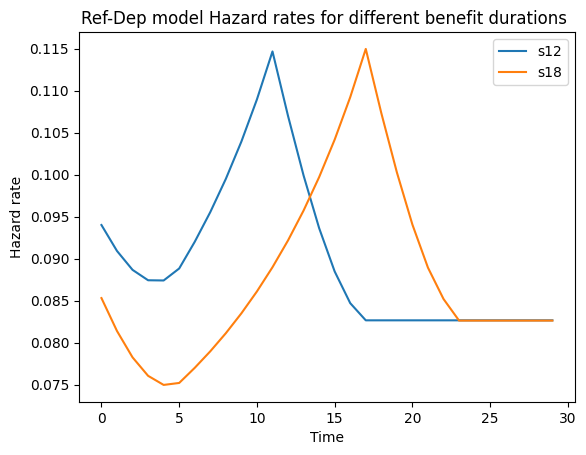

In [371]:
# plot s12 and s18 alongside each other
plt.plot(s12, label='s12')
plt.plot(s18, label='s18')
plt.xlabel('Time')
plt.ylabel('Hazard rate')
plt.title('Ref-Dep model Hazard rates for different benefit durations ')
plt.legend()
plt.show()

This compares much more to the Schmieder model as we see a decreasing search effort in the beginning, while reference point is decreasing (diminished by more periods with benefit), then we see an increase in search effort towards the beginning of welfare period, this is the loss-aversion parameter playing a role. Afer welfare we once again see search effort going down as reference point is now diminishing with more periods of welfare.

#### Plotting Reference Points

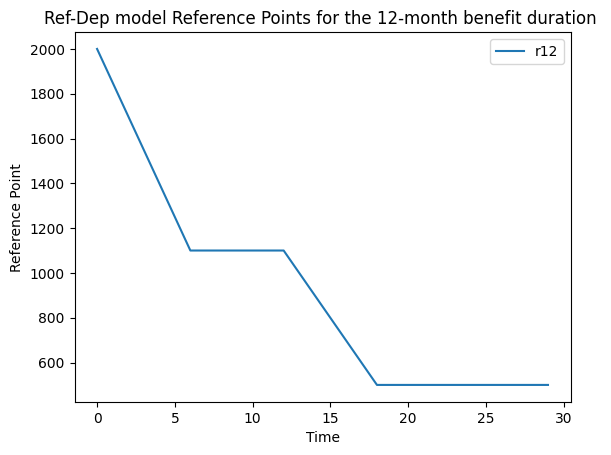

In [372]:
# plot reference repoints r12
plt.plot(r12, label='r12')
plt.xlabel('Time')
plt.ylabel('Reference Point')
plt.title('Ref-Dep model Reference Points for the 12-month benefit duration ')
plt.legend()
plt.show()

We see that the reference point decreases for the first 6 periods, that is when pre UI wage still plays a role for the reference point. Then it plateaus in period 7, and until period 13. In these periods the reference point is only made up of the benefits. for period 14, welfare enters into the reference point and it start decreasing again until period 19, when reference point is only made up of the welfare benefit.

#### Plotting VE and VU

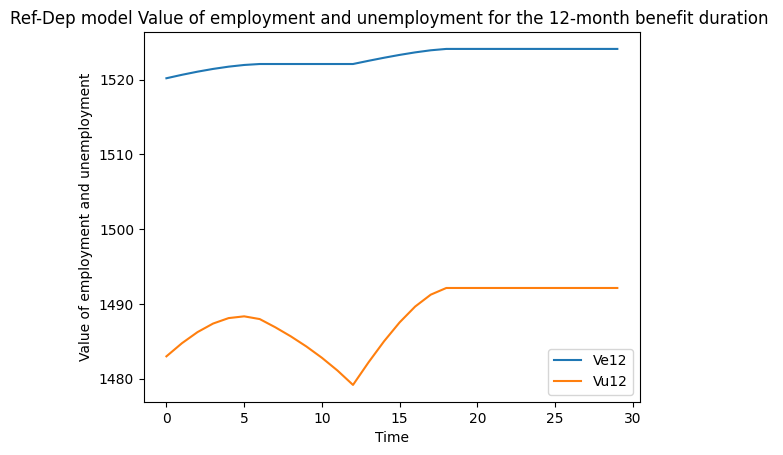

In [373]:
# plot reference repoints r12
plt.plot(Ve12, label='Ve12')
plt.plot(Vu12, label='Vu12')
plt.xlabel('Time')
plt.ylabel('Value of employment and unemployment')
plt.title('Ref-Dep model Value of employment and unemployment for the 12-month benefit duration ')
plt.legend()
plt.show()

Since Value of employment is almost constant, the hazard rate is driven by value of unemployment, such taht is is negatively correlated with Vu. When Vu goes up, search effort (hazard rate) goes down and vice verse

### Multiple types
Adding heterogeneity to the model, in the form of three different types, with 3 different levels of search costs k, so that we now have $k_1, k_2, k_3$. The relative share of these types are also flexible, with share of type 1 being $q_1$, share of type 2 being $q_2$ and share of type 3 being $q_3 \equiv 1-q_1-q_2$

We can solve this by solving the model three times for each of these types, and then aggregating over these three types by computing a weighted average according to the shares $q_i$ (using it as a weight).

In [374]:
eta = 0
lam = 0
N = 0
delta = .995
gamma = .9
k1 = 300
k2 = 30
k3 = 3000
q1= 0.5
q2 = 0.5
params_multi = np.array([eta, lam, N, delta, gamma, k1, k2, k3, q1, q2])

In [375]:
params_multi

array([0.00e+00, 0.00e+00, 0.00e+00, 9.95e-01, 9.00e-01, 3.00e+02,
       3.00e+01, 3.00e+03, 5.00e-01, 5.00e-01])

In [376]:
T = 30
w_pre = 2000
w_post = 2000
ben = model.benefit_path(b1=1100, b2=0, b3=0, welfare=500, T1=12, T2=12, T3=12,T=30)
inst = T, w_pre, w_post, ben

Type 1:

In [377]:
params1 = np.append(params_multi[:5], k1)
r1, s1, surv1, V_E1, V_U1  = model.solveSingleTypeModel(params1, inst)

Type 2:

In [378]:
params2 = np.append(params_multi[:5], k2)
r2, s2, surv2, V_E2, V_U2  = model.solveSingleTypeModel(params2, inst)

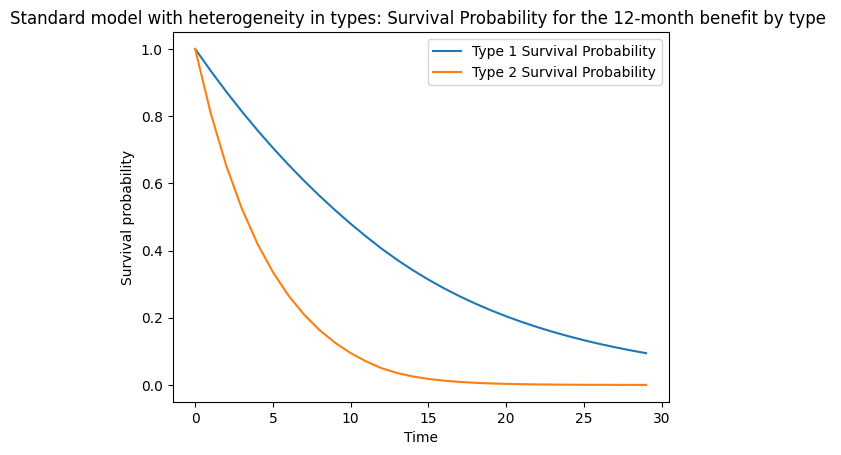

In [379]:
# plot reference repoints r12
plt.plot(surv1, label='Type 1 Survival Probability')
plt.plot(surv2, label='Type 2 Survival Probability')
plt.xlabel('Time')
plt.ylabel('Survival probability')
plt.title('Standard model with heterogeneity in types: Survival Probability for the 12-month benefit by type ')
plt.legend()
plt.show()

In [380]:
rAgg, sAgg, survAgg, V_EAgg, V_UAgg  = model.solveMultiTypeModel(params_multi, inst)

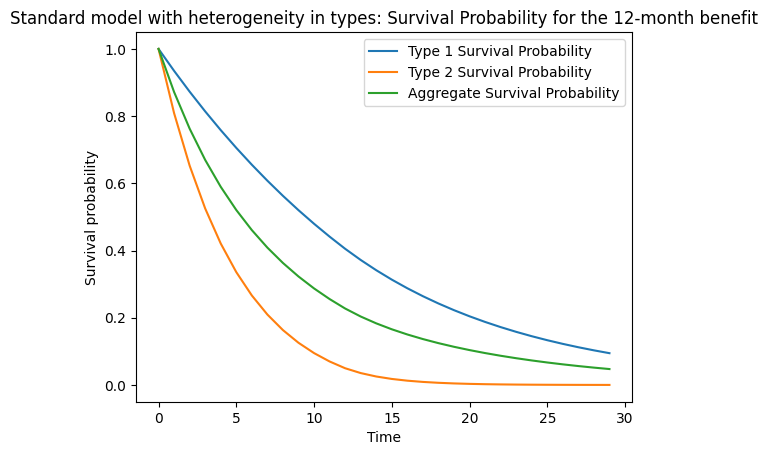

In [381]:
# plot reference repoints r12
plt.plot(surv1, label='Type 1 Survival Probability')
plt.plot(surv2, label='Type 2 Survival Probability')
plt.plot(survAgg, label='Aggregate Survival Probability')
plt.xlabel('Time')
plt.ylabel('Survival probability')
plt.title('Standard model with heterogeneity in types: Survival Probability for the 12-month benefit')
plt.legend()
plt.show()

Type one has a higher search cost, meaning that there survival rate will be higher will be higher, this decreases their search effort

#### Hazard rates in the heterogenous model


In [401]:
eta = 0
lam = 0
N = 0
delta = .995
gamma = .9
k1 = 300
k2 = 50
k3 = 150
q1= 0.33
q2 = 0.4
params_multi = np.array([eta, lam, N, delta, gamma, k1, k2, k3, q1, q2])

In [402]:
T = 30
w_pre = 2000
w_post = 2000
ben = model.benefit_path(b1=1100, b2=0, b3=0, welfare=500, T1=12, T2=12, T3=12,T=30)
inst = T, w_pre, w_post, ben

In [403]:
rAgg, sAgg, survAgg, V_EAgg, V_UAgg  = model.solveMultiTypeModel(params_multi, inst)

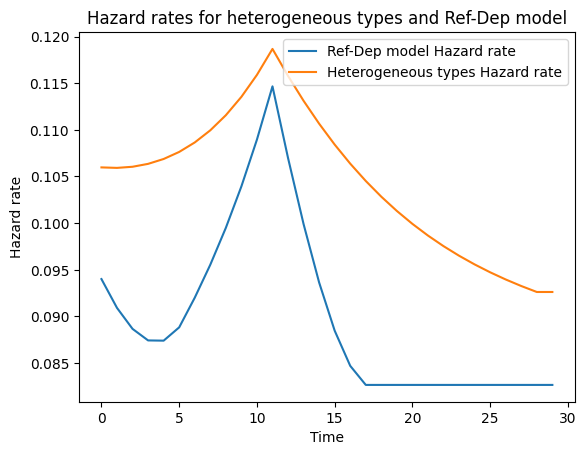

In [404]:
# plot s12 and s18 alongside each other
plt.plot(s12, label='Ref-Dep model Hazard rate')
plt.plot(sAgg, label='Heterogeneous types Hazard rate')
plt.xlabel('Time')
plt.ylabel('Hazard rate')
plt.title('Hazard rates for heterogeneous types and Ref-Dep model')
plt.legend()
plt.show()

#### Disincentive Effects of UI
Calculate duration expected unemployment duration D as $D = \sum^T_{t=1} S_t$ where $S_t$ is the survival rate.
Then estimating the marginal effect of an increase in potential benefit duration P on the expected unemployment Duration. That is $\frac{\partial D}{\partial P}$. We can also calculate the elasticity of D with respect to P, $\eta_{D,P}$

Based on two different UI regimes, that is $\frac{\partial D}{\partial P} = \frac{D_2 - D_1}{P_2-P_1}$ and $\eta_{D,P}=\frac{log(D_2) - log(D_1)}{log(P_2)-log(P_1)} $

In [386]:
#Survival rate from ben12 and ben18, with P=12 and P=18, respectively. 
# First we sum up their expected unemployment duration
D12 = np.sum(surv12)
D18 = np.sum(surv18)

print(f'Expected unemployment duration for ben12: {D12:.4f}')
print(f'Expected unemployment duration for ben18: {D18:.4f}')
print(f'Marginal effect of an increase from 12 to 18 months in the benefit duration: {(D18-D12)/(18-12):.4f}')
print(f'Elasticity of expected unemployment duration with respect to benefit duration: {((np.log(D18)-np.log(D12)))/((np.log(18)-np.log(12))):.4f}')


Expected unemployment duration for ben12: 10.1734
Expected unemployment duration for ben18: 11.0549
Marginal effect of an increase from 12 to 18 months in the benefit duration: 0.1469
Elasticity of expected unemployment duration with respect to benefit duration: 0.2049


## Evidence from Hungary
Each period corresponds to 15 days, first period is omitted and hazard in period t is really the hazard in t+1.
For that reason the model translates period to days using the formula $days = t \cdot 15 + 30$

In [405]:
eta = 0
lam = 0
N = 0
delta = .995
gamma = .9
k = 300
params = np.array([eta, lam, N, delta, gamma, k,])

In [431]:
w_pre = 675
w_post = 675
welfare = 90
b1 = 222
b2 = 222
b3 = 114
T1 = 6
T2 = 18
T3 = 24
T = T3 + 11
# define the benefit path for the pre reform scenario
ben_pre = model.benefit_path(b1=b1, b2=b2, b3=b3, welfare=welfare, T1=T1, T2=T2, T3=T3,T=T)
# define the benefit path for the post reform scenario
b1 = 342
b2 = 171
ben_post = model.benefit_path(b1=b1, b2=b2, b3=b3, welfare=welfare, T1=T1, T2=T2, T3=T3,T=T)

inst_pre = T, w_pre, w_post, ben_pre
inst_post = T, w_pre, w_post, ben_post

# vector with number of days corresponding to each period
timevec = np.arange(T)*15 + 30

In [407]:
inst_pre

(44,
 675,
 675,
 array([222., 222., 222., 222., 222., 222., 222., 222., 222., 222., 222.,
        222., 222., 222., 222., 222., 222., 222., 114., 114., 114., 114.,
        114., 114.,  90.,  90.,  90.,  90.,  90.,  90.,  90.,  90.,  90.,
         90.,  90.,  90.,  90.,  90.,  90.,  90.,  90.,  90.,  90.,  90.]))

#### The two different benefit Paths

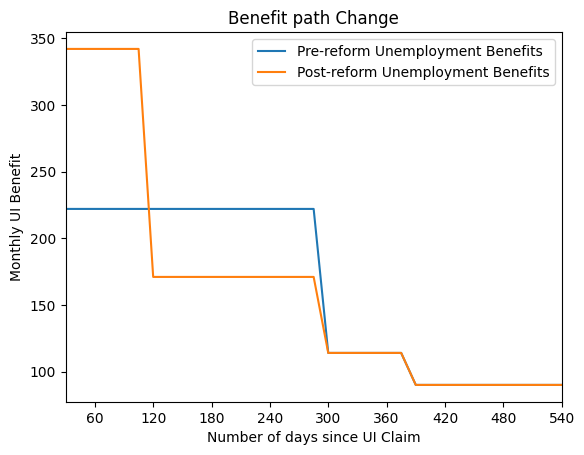

In [432]:
plt.plot(timevec, ben_pre, label='Pre-reform Unemployment Benefits')
plt.plot(timevec, ben_post, label='Post-reform Unemployment Benefits')
plt.xlabel('Number of days since UI Claim')
plt.xlim(timevec[0], timevec[-1]) # set x-axis limits to first and last element in timevec
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(10))  # at most 8 ticks
plt.ylabel('Monthly UI Benefit')
plt.title('Benefit path Change')
plt.legend()
plt.show()

#### Parameters for the Heterogenous Standard Model

In [433]:
eta = 0
lam = 0
N = 0
delta = 0.93
gamma = 0.35
k1 = 173.1
k2 = 49.6
k3 = 12.9
q1= 0.21
q2 = 0.63
params_multi = np.array([eta, lam, N, delta, gamma, k1, k2, k3, q1, q2])

#### Parameters for Reference Dependence model

In [434]:
eta = 1
lam = 4.91
N = 188.4/15
delta = 0.89
gamma = 0.81
k = 359.8
params = np.array([eta, lam, N, delta, gamma, k,])

In [435]:
r_st_pre, s_st_pre, surv_st_pre, V_E_st_pre, V_U_st_pre  = model.solveMultiTypeModel(params_multi, inst_pre)
r_st_post, s_st_post, surv_st_post, V_E_st_post, V_U_st_post  = model.solveMultiTypeModel(params_multi, inst_post)

r_rd_pre, s_rd_pre, surv_rd_pre, V_E_rd_pre, V_U_rd_pre  = model.solveSingleTypeModel(params, inst_pre)
r_rd_post, s_rd_post, surv_rd_post, V_E_rd_post, V_U_rd_post  = model.solveSingleTypeModel(params, inst_post)

In [450]:
hungary = pd.read_excel('base_moments_Hungary.xlsx', index_col=0)
hazard_pre = hungary['before_b'].to_numpy()
hazard_pre = hazard_pre[1:] # Exclude the first element if needed
hazard_post = hungary['after_b'].to_numpy()
hazard_post = hazard_post[1:] # Exclude the first element if needed
target = np.hstack((hazard_pre,hazard_post))


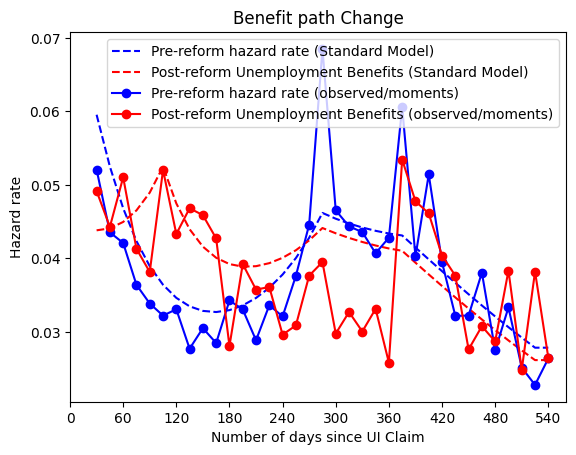

In [451]:
plt.plot(timevec, s_st_pre, label='Pre-reform hazard rate (Standard Model)', linestyle='dashed', color='blue')
plt.plot(timevec, s_st_post, label='Post-reform Unemployment Benefits (Standard Model)', linestyle='dashed', color='red')
plt.plot(timevec, hazard_pre, label='Pre-reform hazard rate (observed/moments)', marker='o', color='blue')
plt.plot(timevec, hazard_post, label='Post-reform Unemployment Benefits (observed/moments)', marker='o', color='red')

plt.xlabel('Number of days since UI Claim')
plt.xlim(0, 560) # set x-axis limits to first and last element in timevec
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(10))  # at most 8 ticks
plt.ylabel('Hazard rate')
plt.title('Benefit path Change')
plt.legend()
plt.show()

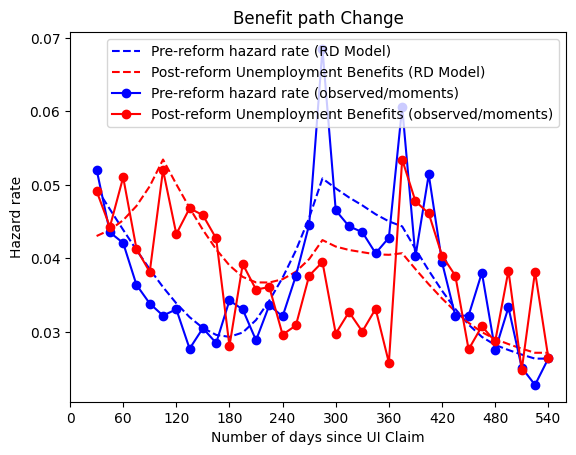

In [452]:

plt.plot(timevec, s_rd_pre, label='Pre-reform hazard rate (RD Model)', linestyle='dashed', color='blue')
plt.plot(timevec, s_rd_post, label='Post-reform Unemployment Benefits (RD Model)', linestyle='dashed', color='red')
plt.plot(timevec, hazard_pre, label='Pre-reform hazard rate (observed/moments)', marker='o', color='blue')
plt.plot(timevec, hazard_post, label='Post-reform Unemployment Benefits (observed/moments)', marker='o', color='red')

plt.xlabel('Number of days since UI Claim')
plt.xlim(0, 560) # set x-axis limits to first and last element in timevec
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(11))  # at most 8 ticks
plt.ylabel('Hazard rate')
plt.title('Benefit path Change')
plt.legend()
plt.show()